In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

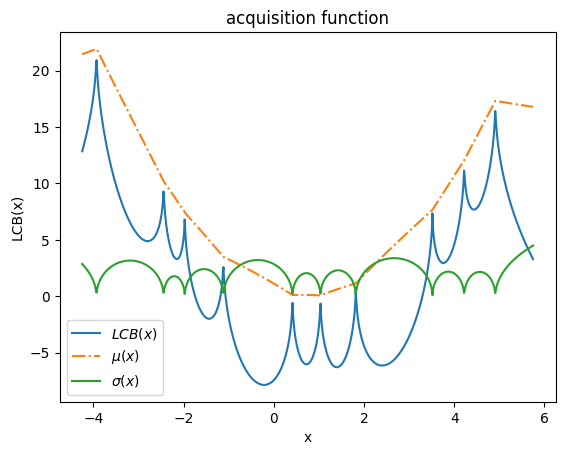

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [6]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 50
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = acqf.evaluate_meansig2(np.atleast_1d(mu_L), np.atleast_1d(s2_U))[0]
        LCB_U = acqf.evaluate_meansig2(np.atleast_1d(mu_U), np.atleast_1d(s2_L))[0]
        #LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

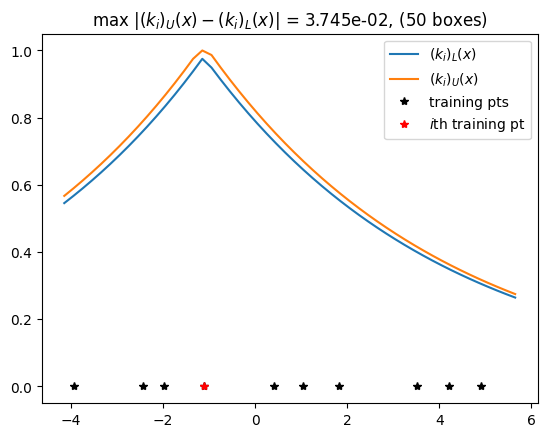

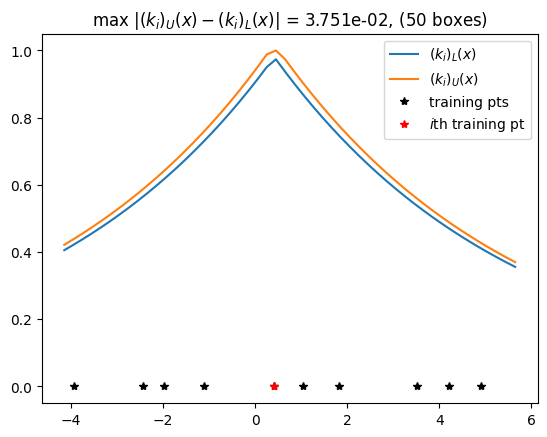

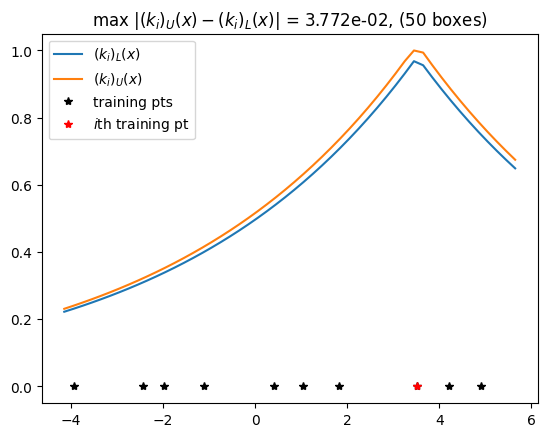

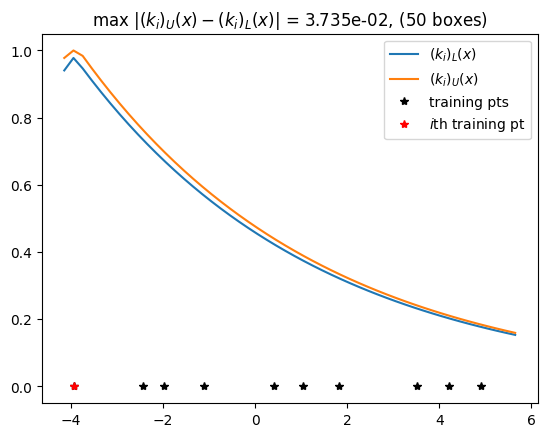

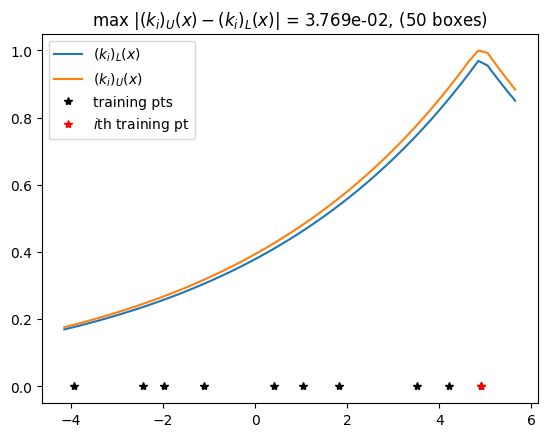

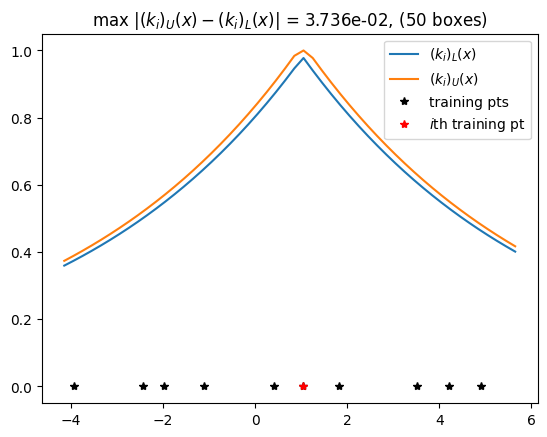

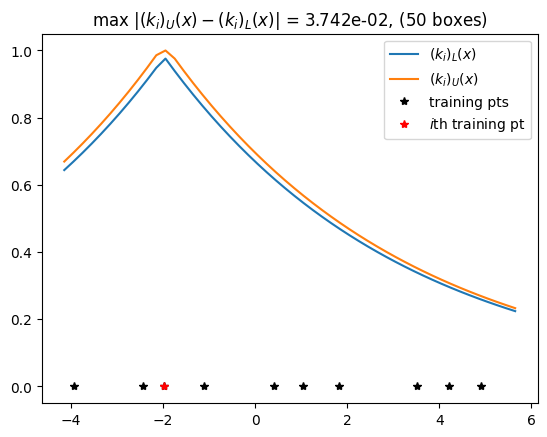

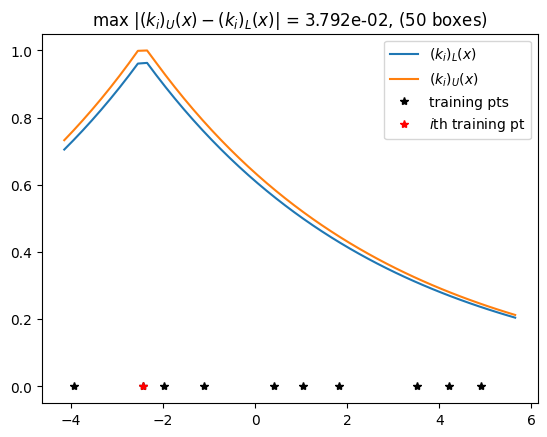

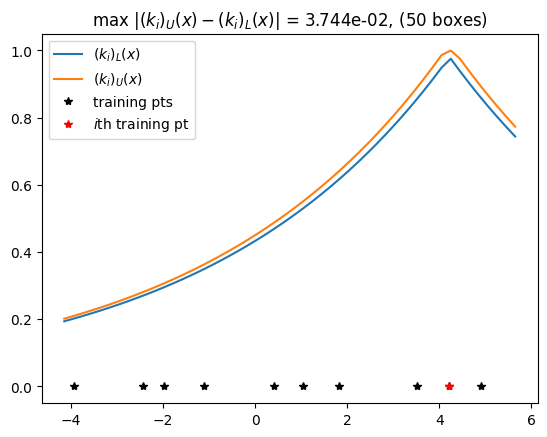

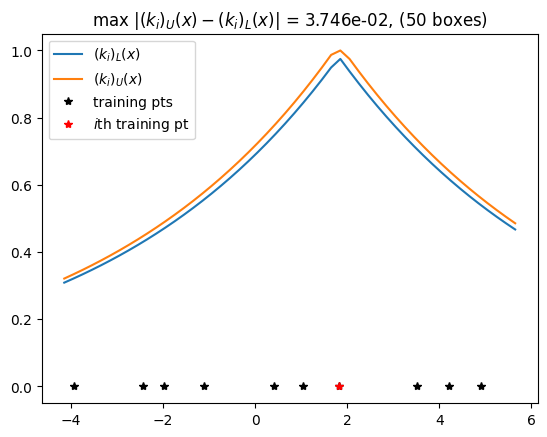

In [7]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

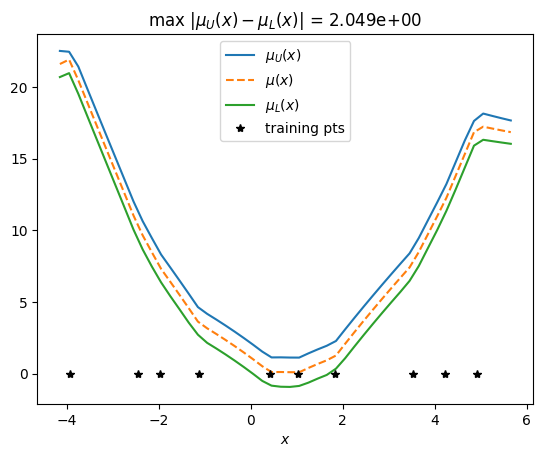

In [8]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

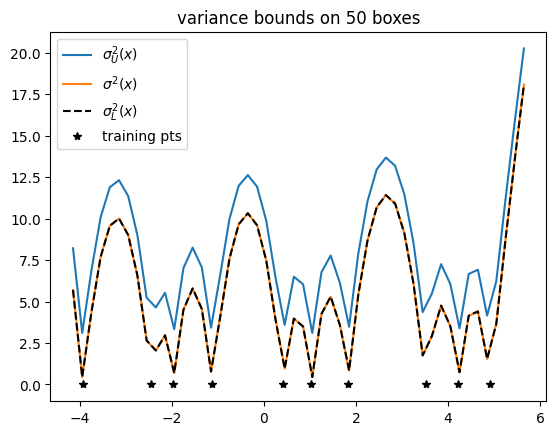

In [9]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(midpoints, s2, label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, "k--", label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

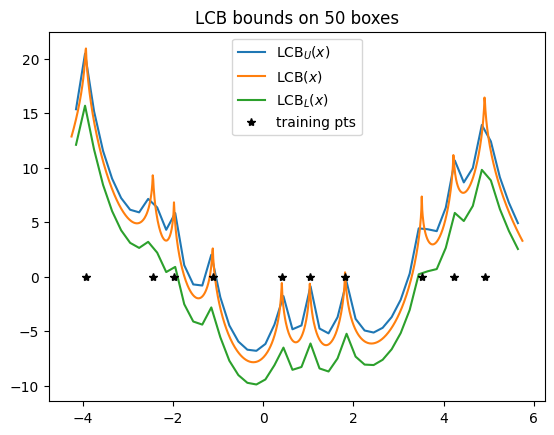

In [10]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [12]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(acqf)
bnb.epsilon_diam = 1.e-3
bnb.epsilon_gap = 1.e-3
bnb.BnB_LBmethod = None
bnb.max_bnbiter = 2000
xstar = bnb.optimize()

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -51.121421894771984
Initial acquisition upper bound: 41.305781835120534

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-51.121421894771984, U=41.305781835120534
Current best feasible value (GUB): 41.305781835120534
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-33.86570624557024, U=23.58939967219383
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-34.032270502010434, U=20.13153820882594
Queue size: 2 | GLB=-34.032270502010434 | GUB=20.13153820882594 | Gap=54.16380871083638

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-34.032270502010434, U=20.13153820882594
Current best feasible value (GUB): 20.13153820882594
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-25.965221344142996, U

  Child acquisition bounds: L=-8.180673879819262, U=-5.421926371329059
  Branching to child: l=[1.53125], u=[1.6875]
  Child acquisition bounds: L=-7.336698498142663, U=-4.434363932237378
Queue size: 17 | GLB=-9.657566531922013 | GUB=-7.049838526641761 | Gap=2.6077280052802525

--- BnB Iteration 22 ---
Node bounds: l=[0.4375], u=[0.75]
Node acquisition bounds: L=-9.657566531922013, U=-3.8747530069777705
Current best feasible value (GUB): -7.049838526641761
  Branching to child: l=[0.4375], u=[0.59375]
  Child acquisition bounds: L=-6.943732417968438, U=-3.657538235374081
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.59375], u=[0.75]
  Child acquisition bounds: L=-8.068209831767259, U=-5.145726883530111
Queue size: 17 | GLB=-9.605528371612042 | GUB=-7.049838526641761 | Gap=2.5556898449702814

--- BnB Iteration 23 ---
Node bounds: l=[1.0625], u=[1.375]
Node acquisition bounds: L=-9.605528371612042, U=-3.932076919960614
Current best feasible value (GUB): -7.049838526641761
  B

  Child acquisition bounds: L=-7.399504039626649, U=-6.164252991567165
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.578125], u=[-0.5]
  Child acquisition bounds: L=-7.845488236911997, U=-6.627991110357221
Queue size: 21 | GLB=-8.443633750430315 | GUB=-7.6585760417068665 | Gap=0.7850577087234489

--- BnB Iteration 40 ---
Node bounds: l=[-0.421875], u=[-0.34375]
Node acquisition bounds: L=-8.443633750430315, U=-7.241248377395355
Current best feasible value (GUB): -7.6585760417068665
  Branching to child: l=[-0.421875], u=[-0.3828125]
  Child acquisition bounds: L=-7.98731493724478, U=-7.383108392323032
  Branching to child: l=[-0.3828125], u=[-0.34375]
  Child acquisition bounds: L=-8.090750840603109, U=-7.486961777677041
Queue size: 22 | GLB=-8.275750295214074 | GUB=-7.6585760417068665 | Gap=0.6171742535072076

--- BnB Iteration 41 ---
Node bounds: l=[-0.03125], u=[0.046875]
Node acquisition bounds: L=-8.275750295214074, U=-7.000388001829231
Current best feasible value (GU

  Child acquisition bounds: L=-7.958553291898994, U=-7.805514428786522
  Branching to child: l=[-0.19726562], u=[-0.1875]
  Child acquisition bounds: L=-7.9554508190205535, U=-7.802206685565056
Queue size: 27 | GLB=-8.059660252961695 | GUB=-7.807314642019012 | Gap=0.25234561094268315

--- BnB Iteration 57 ---
Node bounds: l=[-0.24609375], u=[-0.2265625]
Node acquisition bounds: L=-8.059660252961695, U=-7.755177542013265
Current best feasible value (GUB): -7.807314642019012
  Branching to child: l=[-0.24609375], u=[-0.23632812]
  Child acquisition bounds: L=-7.955125433235836, U=-7.802774030590034
  Branching to child: l=[-0.23632812], u=[-0.2265625]
  Child acquisition bounds: L=-7.958335168466502, U=-7.8058314602593875
Queue size: 28 | GLB=-8.051605971737372 | GUB=-7.807314642019012 | Gap=0.24429132971835976

--- BnB Iteration 58 ---
Node bounds: l=[-0.1875], u=[-0.16796875]
Node acquisition bounds: L=-8.051605971737372, U=-7.744837006767989
Current best feasible value (GUB): -7.80731

  Child acquisition bounds: L=-7.904589996040087, U=-7.828349377631875
Queue size: 39 | GLB=-7.9507392374188655 | GUB=-7.832108298606011 | Gap=0.11863093881285458

--- BnB Iteration 76 ---
Node bounds: l=[-0.1875], u=[-0.17773438]
Node acquisition bounds: L=-7.9507392374188655, U=-7.797275931390072
Current best feasible value (GUB): -7.832108298606011
  Branching to child: l=[-0.1875], u=[-0.18261719]
  Child acquisition bounds: L=-7.900095302458092, U=-7.823343192669827
  Branching to child: l=[-0.18261719], u=[-0.17773438]
  Child acquisition bounds: L=-7.897280205804343, U=-7.820471307007661
Queue size: 40 | GLB=-7.950363926470608 | GUB=-7.832108298606011 | Gap=0.1182556278645972

--- BnB Iteration 77 ---
Node bounds: l=[-0.25585938], u=[-0.24609375]
Node acquisition bounds: L=-7.950363926470608, U=-7.798152139916641
Current best feasible value (GUB): -7.832108298606011
  Branching to child: l=[-0.25585938], u=[-0.25097656]
  Child acquisition bounds: L=-7.897548372663157, U=-7.8214

...

  Child acquisition bounds: L=-7.860919663824075, U=-7.851379986601416
Queue size: 119 | GLB=-7.867101466060474 | GUB=-7.853724862097276 | Gap=0.01337660396319773

--- BnB Iteration 191 ---
Node bounds: l=[-0.17529297], u=[-0.17285156]
Node acquisition bounds: L=-7.867101466060474, U=-7.828647942985844
Current best feasible value (GUB): -7.853724862097276
  Branching to child: l=[-0.17529297], u=[-0.17407227]
  Child acquisition bounds: L=-7.8544935873485695, U=-7.835265615107877
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.17407227], u=[-0.17285156]
  Child acquisition bounds: L=-7.853599866802599, U=-7.8343681364084645
  Child pruned: L ≥ GUB - eps.
Queue size: 118 | GLB=-7.866999040205889 | GUB=-7.853724862097276 | Gap=0.0132741781086132

--- BnB Iteration 192 ---
Node bounds: l=[-0.19970703], u=[-0.19848633]
Node acquisition bounds: L=-7.866999040205889, U=-7.84784034886571
Current best feasible value (GUB): -7.853724862097276
  Branching to child: l=[-0.19970703], u=

  Child acquisition bounds: L=-7.850959404056899, U=-7.83193520561683
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.2644043], u=[-0.26318359]
  Child acquisition bounds: L=-7.851903371382028, U=-7.83287734382312
  Child pruned: L ≥ GUB - eps.
Queue size: 126 | GLB=-7.864248594672497 | GUB=-7.853724862097276 | Gap=0.01052373257522099

--- BnB Iteration 210 ---
Node bounds: l=[-0.24365234], u=[-0.24243164]
Node acquisition bounds: L=-7.864248594672497, U=-7.84518773814935
Current best feasible value (GUB): -7.853724862097276
  Branching to child: l=[-0.24365234], u=[-0.24304199]
  Child acquisition bounds: L=-7.8576717540304335, U=-7.848140878015364
  Branching to child: l=[-0.24304199], u=[-0.24243164]
  Child acquisition bounds: L=-7.85793106106198, U=-7.8483996201974
Queue size: 127 | GLB=-7.86377915953301 | GUB=-7.853724862097276 | Gap=0.01005429743573405

--- BnB Iteration 211 ---
Node bounds: l=[-0.19116211], u=[-0.18994141]
Node acquisition bounds: L=-7.86377915953301

  Child acquisition bounds: L=-7.834684692589594, U=-7.7967141880472495
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.29248047], u=[-0.29003906]
  Child acquisition bounds: L=-7.837677449715819, U=-7.799701824067885
  Child pruned: L ≥ GUB - eps.
Queue size: 88 | GLB=-7.861727988830595 | GUB=-7.853724862097276 | Gap=0.008003126733319377

--- BnB Iteration 266 ---
Node bounds: l=[-0.20397949], u=[-0.20336914]
Node acquisition bounds: L=-7.861727988830595, U=-7.852153777588118
Current best feasible value (GUB): -7.853724862097276
Skip: Node diameter 0.0006103515625 <= 0.001

--- BnB Iteration 267 ---
Node bounds: l=[-0.23144531], u=[-0.23083496]
Node acquisition bounds: L=-7.861695986631496, U=-7.852153218296599
Current best feasible value (GUB): -7.853724862097276
Skip: Node diameter 0.0006103515625 <= 0.001

--- BnB Iteration 268 ---
Node bounds: l=[-0.20336914], u=[-0.20275879]
Node acquisition bounds: L=-7.861585408826487, U=-7.852010423338265
Current best feasible value

  Child acquisition bounds: L=-7.621001001423405, U=-7.3173974010171055
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.44140625], u=[-0.421875]
  Child acquisition bounds: L=-7.690888057657332, U=-7.387675083223415
  Child pruned: L ≥ GUB - eps.
Queue size: 66 | GLB=-7.8602185171859835 | GUB=-7.853724862097276 | Gap=0.006493655088707584

--- BnB Iteration 291 ---
Node bounds: l=[-0.19848633], u=[-0.19787598]
Node acquisition bounds: L=-7.8602185171859835, U=-7.850637216933456
Current best feasible value (GUB): -7.853724862097276
Skip: Node diameter 0.0006103515625 <= 0.001

--- BnB Iteration 292 ---
Node bounds: l=[-0.23693848], u=[-0.23632812]
Node acquisition bounds: L=-7.860188175162107, U=-7.850650913969583
Current best feasible value (GUB): -7.853724862097276
Skip: Node diameter 0.0006103515625 <= 0.001

--- BnB Iteration 293 ---
Node bounds: l=[-0.18383789], u=[-0.18261719]
Node acquisition bounds: L=-7.860030152001205, U=-7.84082769277155
Current best feasible value 

  Child acquisition bounds: L=-7.850427702176874, U=-7.840908470295881
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.25646973], u=[-0.25585938]
  Child acquisition bounds: L=-7.85082070068331, U=-7.8413009717944675
  Child pruned: L ≥ GUB - eps.
Queue size: 25 | GLB=-7.857020327132825 | GUB=-7.853724862097276 | Gap=0.0032954650355492277

--- BnB Iteration 332 ---
Node bounds: l=[-0.17895508], u=[-0.17773438]
Node acquisition bounds: L=-7.857020327132825, U=-7.837803458523652
Current best feasible value (GUB): -7.853724862097276
  Branching to child: l=[-0.17895508], u=[-0.17834473]
  Child acquisition bounds: L=-7.850699177984926, U=-7.841090431748114
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.17834473], u=[-0.17773438]
  Child acquisition bounds: L=-7.850296439340522, U=-7.840686777962012
  Child pruned: L ≥ GUB - eps.
Queue size: 24 | GLB=-7.8569079966781254 | GUB=-7.853724862097276 | Gap=0.0031831345808495115

--- BnB Iteration 333 ---
Node bounds: l=[-0

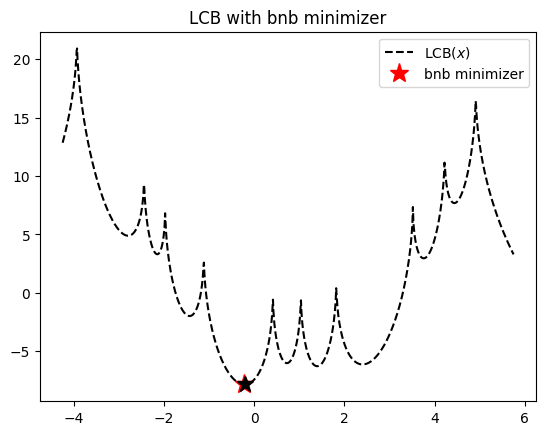

In [13]:
y_star = acqf.evaluate(xstar)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
#print(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
plt.plot(xstar_true, ystar_true, "k*", markersize=12)
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()


In [14]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': "SLSQP"    
}

In [15]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 3
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver options: {'maxiter': 200}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 8.0139e-02 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 8.0139e-02
hiopbbpy *****************************
hiopbbpy Iteration 1/3
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -51.12142266105249
Initial acquisition upper bound: 41.305782446669475

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-51.12142266105249, U=41.305782446669475
Current best feasible value (GUB): 41.305782446669475
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-33.86570658104098, U=23.589400005024856
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-34.03227084720669, U=20.131538574879364
Queue size: 2 | GLB=-34.03227084720669 | GUB=20.131538574879364 | Gap=54.163809422086054

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-34.03227084720669, U=20.131538574879364
Current best feasible value (GUB): 20.131538574879364
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-25.96522148527898, U

  Child acquisition bounds: L=-9.409631609342252, U=-6.966803377148643
  Branching to child: l=[-0.03125], u=[0.125]
  Child acquisition bounds: L=-8.975309818563378, U=-6.416557499873772
Queue size: 15 | GLB=-10.850867107252832 | GUB=-6.966803377148643 | Gap=3.884063730104189

--- BnB Iteration 19 ---
Node bounds: l=[-0.5], u=[-0.1875]
Node acquisition bounds: L=-10.850867107252832, U=-6.1549879761429676
Current best feasible value (GUB): -6.966803377148643
  Branching to child: l=[-0.5], u=[-0.34375]
  Child acquisition bounds: L=-9.119423872902406, U=-6.732212304015892
  Branching to child: l=[-0.34375], u=[-0.1875]
  Child acquisition bounds: L=-9.441821395204375, U=-7.049838476461417
Queue size: 16 | GLB=-10.015912225529156 | GUB=-7.049838476461417 | Gap=2.966073749067739

--- BnB Iteration 20 ---
Node bounds: l=[2.625], u=[3.25]
Node acquisition bounds: L=-10.015912225529156, U=-1.0243715000622213
Current best feasible value (GUB): -7.049838476461417
  Branching to child: l=[2.62

  Child acquisition bounds: L=-8.170684048679789, U=-7.56658316089405
  Branching to child: l=[-0.3046875], u=[-0.265625]
  Child acquisition bounds: L=-8.227072179592717, U=-7.62192632470994
Queue size: 20 | GLB=-8.51699966685025 | GUB=-7.658575999379339 | Gap=0.8584236674709107

--- BnB Iteration 38 ---
Node bounds: l=[-0.109375], u=[-0.03125]
Node acquisition bounds: L=-8.51699966685025, U=-7.272210554234593
Current best feasible value (GUB): -7.658575999379339
  Branching to child: l=[-0.109375], u=[-0.0703125]
  Child acquisition bounds: L=-8.140593916974566, U=-7.517923614565735
  Branching to child: l=[-0.0703125], u=[-0.03125]
  Child acquisition bounds: L=-8.043286152336464, U=-7.414078823277701
Queue size: 21 | GLB=-8.444721884879428 | GUB=-7.658575999379339 | Gap=0.7861458855000887

--- BnB Iteration 39 ---
Node bounds: l=[-0.65625], u=[-0.5]
Node acquisition bounds: L=-8.444721884879428, U=-6.01714735718552
Current best feasible value (GUB): -7.658575999379339
  Branching t

  Child acquisition bounds: L=-7.959983505857308, U=-7.807314601449109
  Branching to child: l=[-0.21679688], u=[-0.20703125]
  Child acquisition bounds: L=-7.960060025999406, U=-7.807212817112886
Queue size: 26 | GLB=-8.060615038372074 | GUB=-7.807314601449109 | Gap=0.2533004369229648

--- BnB Iteration 56 ---
Node bounds: l=[-0.20703125], u=[-0.1875]
Node acquisition bounds: L=-8.060615038372074, U=-7.754715867678897
Current best feasible value (GUB): -7.807314601449109
  Branching to child: l=[-0.20703125], u=[-0.19726562]
  Child acquisition bounds: L=-7.9585532527379454, U=-7.805514388352928
  Branching to child: l=[-0.19726562], u=[-0.1875]
  Child acquisition bounds: L=-7.955450779932316, U=-7.802206645206507
Queue size: 27 | GLB=-8.059660214242136 | GUB=-7.807314601449109 | Gap=0.25234561279302703

--- BnB Iteration 57 ---
Node bounds: l=[-0.24609375], u=[-0.2265625]
Node acquisition bounds: L=-8.059660214242136, U=-7.755177500733936
Current best feasible value (GUB): -7.807314

...

  Child acquisition bounds: L=-5.609496279947133, U=-5.233347587143019
  Branching to child: l=[0.76953125], u=[0.7890625]
  Child acquisition bounds: L=-5.559977858284001, U=-5.182135900986265
Queue size: 35 | GLB=-5.822881133460644 | GUB=-5.26981221538538 | Gap=0.5530689180752644

--- BnB Iteration 62 ---
Node bounds: l=[1.21875], u=[1.375]
Node acquisition bounds: L=-5.822881133460644, U=-2.47659767120602
Current best feasible value (GUB): -5.26981221538538
  Branching to child: l=[1.21875], u=[1.296875]
  Child acquisition bounds: L=-4.982678437654577, U=-3.301888324088182
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[1.296875], u=[1.375]
  Child acquisition bounds: L=-4.103249428540434, U=-2.1913479139137606
  Child pruned: L ≥ GUB - eps.
Queue size: 34 | GLB=-5.811889139577694 | GUB=-5.26981221538538 | Gap=0.5420769241923145

--- BnB Iteration 63 ---
Node bounds: l=[2.46875], u=[2.546875]
Node acquisition bounds: L=-5.811889139577694, U=-4.618714358564576
Current best f

  Child acquisition bounds: L=-5.351972297007297, U=-5.043728177248077
Queue size: 38 | GLB=-5.546688208096898 | GUB=-5.323159538170816 | Gap=0.22352866992608256

--- BnB Iteration 83 ---
Node bounds: l=[2.390625], u=[2.4296875]
Node acquisition bounds: L=-5.546688208096898, U=-4.939836385174787
Current best feasible value (GUB): -5.323159538170816
  Branching to child: l=[2.390625], u=[2.41015625]
  Child acquisition bounds: L=-5.352261541174483, U=-5.0476855278775945
  Branching to child: l=[2.41015625], u=[2.4296875]
  Child acquisition bounds: L=-5.341379334463944, U=-5.037830015703092
Queue size: 39 | GLB=-5.544117631523233 | GUB=-5.323159538170816 | Gap=0.2209580933524169

--- BnB Iteration 84 ---
Node bounds: l=[0.0859375], u=[0.125]
Node acquisition bounds: L=-5.544117631523233, U=-4.80285707948592
Current best feasible value (GUB): -5.323159538170816
  Branching to child: l=[0.0859375], u=[0.10546875]
  Child acquisition bounds: L=-5.27194193665245, U=-4.899052983962649
  Chil

  Child acquisition bounds: L=-4.948158163098938, U=-4.253772473750967
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.5390625], u=[-0.5]
  Child acquisition bounds: L=-4.892794823426048, U=-4.189795656449722
  Child pruned: L ≥ GUB - eps.
Queue size: 18 | GLB=-5.399836961511699 | GUB=-5.323159538170816 | Gap=0.07667742334088334

--- BnB Iteration 111 ---
Node bounds: l=[-0.65625], u=[-0.578125]
Node acquisition bounds: L=-5.399836961511699, U=-4.037314713195093
Current best feasible value (GUB): -5.323159538170816
  Branching to child: l=[-0.65625], u=[-0.6171875]
  Child acquisition bounds: L=-4.906219391254611, U=-4.2208584289298345
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.6171875], u=[-0.578125]
  Child acquisition bounds: L=-4.951746483823492, U=-4.263108250132207
  Child pruned: L ≥ GUB - eps.
Queue size: 17 | GLB=-5.394112584303376 | GUB=-5.323159538170816 | Gap=0.07095304613256026

--- BnB Iteration 112 ---
Node bounds: l=[0.80859375], u=[0.828125]


hiopbbpy   (mu, sigma) at new sample x: 0.11317167353067248, 1.8298330527650797 
hiopbbpy Best objective found in this iteration: 5.9605e-04 
hiopbbpy Training set size is now 13
hiopbbpy Current best objective: 5.9605e-04 (previous best: 4.0915e-01)
hiopbbpy Objective function improvement: 4.0855e-01
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Optimal at BO iteration: 3 
hiopbbpy Best value: 0.0005960464477539062
hiopbbpy ===================================


  Child acquisition bounds: L=-5.247422788086785, U=-5.092949200471447
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[2.34179688], u=[2.3515625]
  Child acquisition bounds: L=-5.252067913141993, U=-5.097942917303568
  Child pruned: L ≥ GUB - eps.
Queue size: 5 | GLB=-5.346438580160579 | GUB=-5.323159538170816 | Gap=0.02327904198976327

--- BnB Iteration 124 ---
Node bounds: l=[0.64257812], u=[0.65234375]
Node acquisition bounds: L=-5.346438580160579, U=-5.1555911838796575
Current best feasible value (GUB): -5.323159538170816
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 125 ---
Node bounds: l=[2.41015625], u=[2.4296875]
Node acquisition bounds: L=-5.341379334463944, U=-5.037830015703092
Current best feasible value (GUB): -5.323159538170816
  Branching to child: l=[2.41015625], u=[2.41992188]
  Child acquisition bounds: L=-5.244660087491392, U=-5.092603292061511
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[2.41992188], u=[2.4296875]
  Child acquisition b

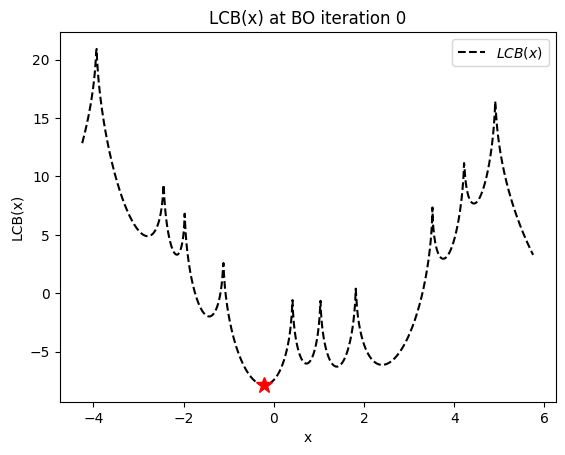

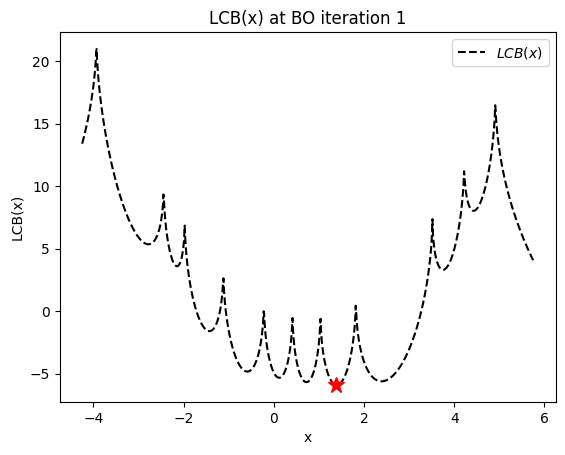

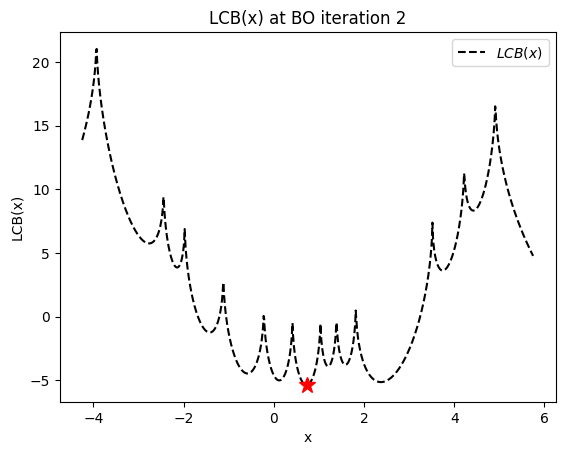

In [16]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    